<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Departamento_de_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Departamento de marketing

## Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
credit_cards_df = pd.read_csv("/content/Marketing_data.csv")

In [3]:
credit_cards_df.shape

(8950, 18)

In [4]:
credit_cards_df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
credit_cards_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
credit_cards_df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Visualização e exploração dos dados

<Axes: >

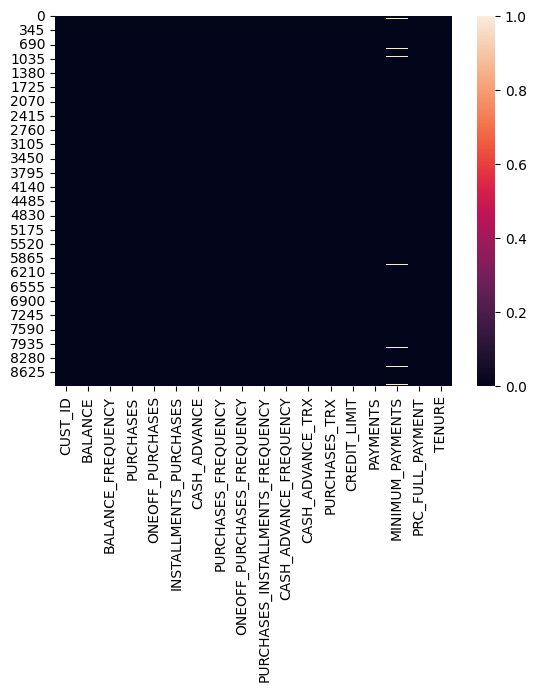

In [7]:
sns.heatmap(credit_cards_df.isnull())

In [8]:
credit_cards_df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [9]:
credit_cards_df.loc[(credit_cards_df["MINIMUM_PAYMENTS"].isnull() == True), "MINIMUM_PAYMENTS"] = credit_cards_df["MINIMUM_PAYMENTS"].mean()

In [10]:
credit_cards_df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [11]:
credit_cards_df.loc[(credit_cards_df["CREDIT_LIMIT"].isnull() == True), "CREDIT_LIMIT"] = credit_cards_df["CREDIT_LIMIT"].mean()

In [12]:
credit_cards_df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [13]:
credit_cards_df.duplicated().sum()

np.int64(0)

In [14]:
credit_cards_df.head(1)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.4,0.0,95.4,0.0,0.166667,0.0,0.083333,0.0,0,2,1000.0,201.802084,139.509787,0.0,12


In [15]:
credit_cards_df.drop(labels = ["CUST_ID"], axis = 1, inplace = True)

In [16]:
credit_cards_df.head(1)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.4,0.0,95.4,0.0,0.166667,0.0,0.083333,0.0,0,2,1000.0,201.802084,139.509787,0.0,12


In [17]:
credit_cards_df.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY',
       'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY',
       'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX',
       'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT',
       'TENURE'],
      dtype='object')

/tmp/ipython-input-530161944.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(credit_cards_df[credit_cards_df.columns[i]], kde = True)
/tmp/ipython-input-530161944.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(credit_cards_df[credit_cards_df.columns[i]], kde = True)
/tmp/ipython-input-5

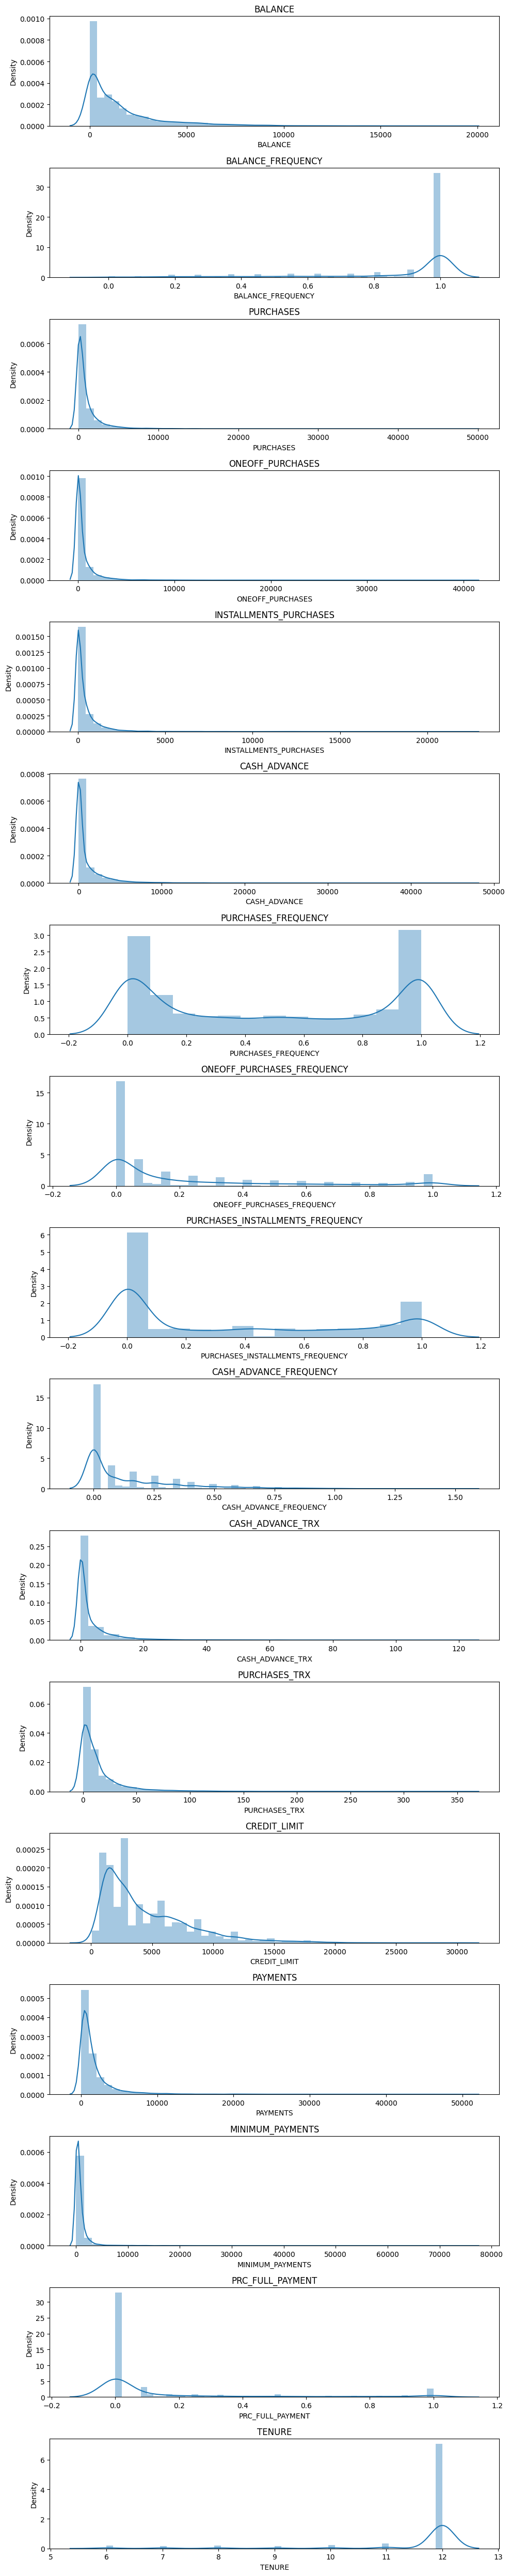

In [18]:
plt.figure(figsize = (10, 50))
for i in range(len(credit_cards_df.columns)):
  plt.subplot(17, 1, i + 1)
  sns.distplot(credit_cards_df[credit_cards_df.columns[i]], kde = True)
  plt.title(credit_cards_df.columns[i])
plt.tight_layout();

In [19]:
correlations = credit_cards_df.corr()

<Axes: >

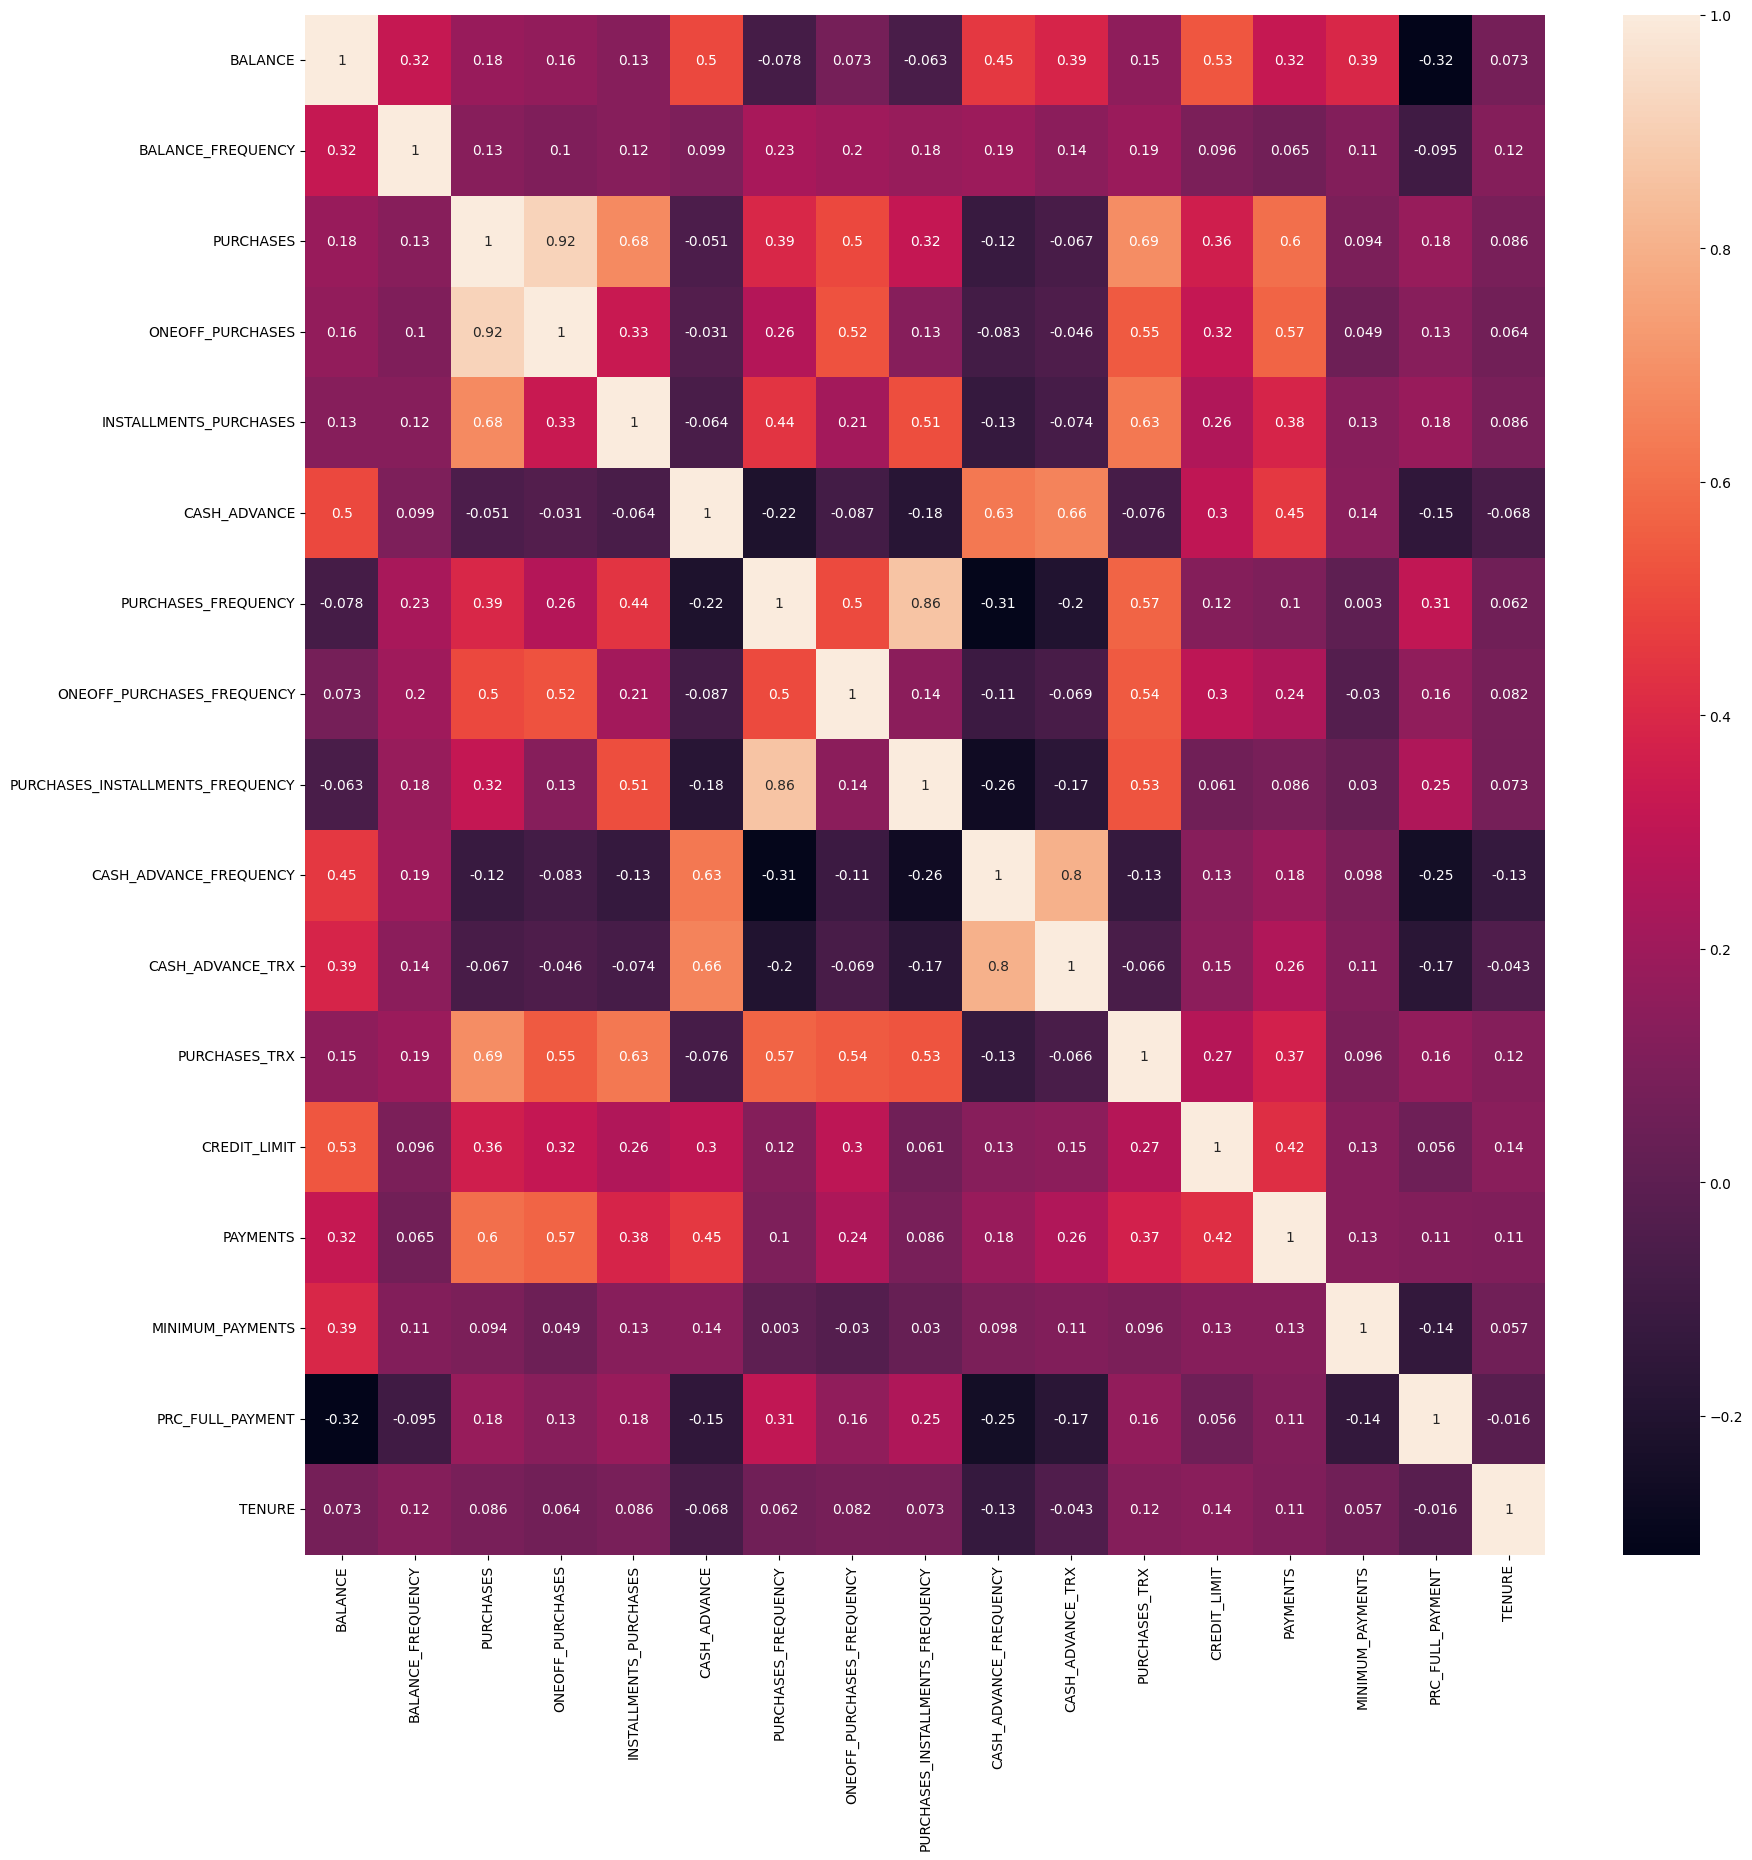

In [20]:
f, ax = plt.subplots(figsize = (20, 20))
sns.heatmap(correlations, annot = True)

## Definição do número de clusters usando o Elbow Method

In [21]:
min(credit_cards_df["BALANCE"]), max(credit_cards_df["BALANCE"])

(0.0, 19043.13856)

In [22]:
scaler = StandardScaler()
credit_cards_df_scaled = scaler.fit_transform(credit_cards_df)

credit_cards_df_scaled

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

In [23]:
min(credit_cards_df_scaled[0]), max(credit_cards_df_scaled[0])

(np.float64(-0.9604333444542572), np.float64(0.36067954425377496))

In [24]:
wcss_1 = []
range_values = range(1, 20)
for i in range_values:
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(credit_cards_df_scaled)
  wcss_1.append(kmeans.inertia_)

In [25]:
wcss_1

[152149.99999999875,
 127785.33381284251,
 111986.8954645705,
 104749.31258227972,
 92157.1820760986,
 86396.89632036588,
 79882.93606211458,
 77103.22240566972,
 71076.98761683275,
 73018.88675615599,
 64195.62982768559,
 61955.5286403948,
 59146.97746998931,
 57499.11121877118,
 56482.84939794577,
 56628.9828491553,
 53437.61140038452,
 52038.94448443119,
 51321.737805598845]

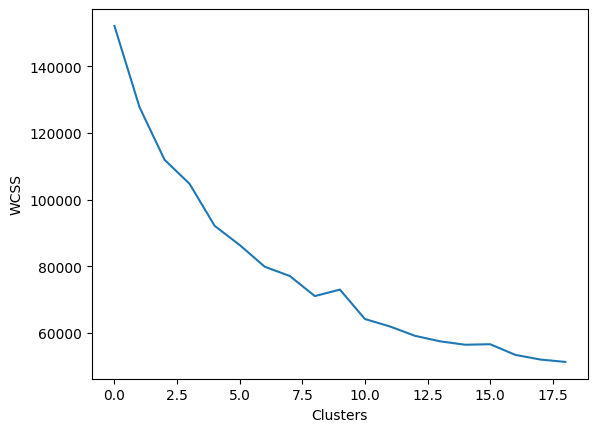

In [26]:
plt.plot(wcss_1)
plt.xlabel("Clusters")
plt.ylabel("WCSS");

## Agrupamento com k-means

In [27]:
kmeans = KMeans(n_clusters = 8)
kmeans.fit(credit_cards_df_scaled)
labels = kmeans.labels_

In [29]:
labels, len(labels)

(array([0, 6, 3, ..., 7, 0, 5], dtype=int32), 8950)

In [30]:
np.unique(labels, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32),
 array([2641,  417,  193, 1126,   30, 1282, 1131, 2130]))

In [32]:
kmeans.cluster_centers_

array([[-1.17799668e-01,  3.67980574e-01, -3.55791259e-01,
        -2.39870455e-01, -4.00459416e-01, -1.69095817e-01,
        -8.44155730e-01, -3.90180723e-01, -7.51454543e-01,
         2.54296244e-03, -1.16194028e-01, -4.82846860e-01,
        -4.12473561e-01, -2.96682083e-01, -8.15979631e-02,
        -4.53575796e-01,  3.53000050e-02],
       [ 9.33456198e-01,  4.67171560e-01,  2.24828349e+00,
         1.69866504e+00,  2.19531371e+00, -1.94698293e-01,
         1.16300431e+00,  1.53538706e+00,  1.26055555e+00,
        -3.07954592e-01, -2.11110389e-01,  2.80162375e+00,
         1.21536013e+00,  1.24000511e+00,  6.19443922e-01,
         2.69352725e-01,  3.33800365e-01],
       [ 1.76492833e+00,  3.35946445e-01,  2.10228937e-02,
         2.56817610e-02,  2.19962220e-03,  4.05481179e+00,
        -2.01725241e-01,  6.09333190e-02, -1.62690883e-01,
         2.54603381e+00,  3.72791658e+00,  1.08400139e-02,
         1.29749991e+00,  2.70444625e+00,  5.59241949e-01,
        -1.89474605e-01,  3.9

In [41]:
cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [credit_cards_df.columns])

In [42]:
cluster_centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.117800,0.367981,-0.355791,-0.239870,-0.400459,-0.169096,-0.844156,-0.390181,-0.751455,0.002543,-0.116194,-0.482847,-0.412474,-0.296682,-0.081598,-0.453576,0.035300
1,0.933456,0.467172,2.248283,1.698665,2.195314,-0.194698,1.163004,1.535387,1.260556,-0.307955,-0.211110,2.801624,1.215360,1.240005,0.619444,0.269353,0.333800
2,1.764928,0.335946,0.021023,0.025682,0.002200,4.054812,-0.201725,0.060933,-0.162691,2.546034,3.727917,0.010840,1.297500,2.704446,0.559242,-0.189475,0.039327
3,-0.172767,0.383882,0.476841,0.617068,-0.006333,-0.339150,0.948894,1.874306,0.108137,-0.413332,-0.333698,0.536146,0.379250,0.098425,-0.169456,0.414868,0.186810
4,1.923051,0.337717,11.212042,10.600367,7.033118,0.419625,1.046983,1.915501,0.981334,-0.258912,0.061229,5.362438,3.044064,8.098975,1.120318,1.110132,0.310863
5,-0.698786,-2.148848,-0.318380,-0.237590,-0.316208,-0.309527,-0.565137,-0.438561,-0.456990,-0.484303,-0.362910,-0.427670,-0.214817,-0.224974,-0.254877,0.254555,-0.161573
6,1.297778,0.372906,-0.306831,-0.219970,-0.321417,1.137886,-0.639833,-0.324276,-0.556013,1.525501,1.137898,-0.383916,0.677012,0.174267,0.434243,-0.445977,-0.174480
7,-0.400879,0.309483,-0.056358,-0.253171,0.331823,-0.364154,1.000783,-0.403986,1.198990,-0.469938,-0.362625,0.151520,-0.317626,-0.243182,-0.074141,0.375473,-0.025921


In [43]:
cluster_centers = scaler.inverse_transform(cluster_centers)

In [44]:
cluster_centers

array([[1.31928476e+03, 9.64441926e-01, 2.43051325e+02, 1.94301545e+02,
        4.89371640e+01, 6.24269284e+02, 1.51550061e-01, 8.60592052e-02,
        6.57900875e-02, 1.35653073e-01, 2.45588792e+00, 2.70806513e+00,
        2.99370188e+03, 8.74278292e+02, 6.74045931e+02, 2.10515047e-02,
        1.15645589e+01],
       [3.50738511e+03, 9.87939355e-01, 5.80669717e+03, 3.41187343e+03,
        2.39626259e+03, 5.70579698e+02, 9.57120379e-01, 6.60493427e-01,
        8.65414357e-01, 7.35193429e-02, 1.80815348e+00, 8.43477218e+01,
        8.91642686e+03, 5.32283716e+03, 2.30779447e+03, 2.32495703e-01,
        1.19640288e+01],
       [5.23802417e+03, 9.56853337e-01, 1.04812057e+03, 6.35063834e+02,
        4.13056736e+02, 9.48200085e+03, 4.09388461e-01, 2.20635275e-01,
        2.99779824e-01, 6.44631554e-01, 2.86891192e+01, 1.49792746e+01,
        9.21528497e+03, 9.56225076e+03, 2.16749631e+03, 9.82965751e-02,
        1.15699482e+01],
       [1.20487588e+03, 9.68208915e-01, 2.02198372e+03, 1.616

In [45]:
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [credit_cards_df.columns])
cluster_centers

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,1319.284762,0.964442,243.051325,194.301545,48.937164,624.269284,0.151550,0.086059,0.065790,0.135653,2.455888,2.708065,2993.701881,874.278292,674.045931,0.021052,11.564559
1,3507.385110,0.987939,5806.697170,3411.873429,2396.262590,570.579698,0.957120,0.660493,0.865414,0.073519,1.808153,84.347722,8916.426859,5322.837159,2307.794473,0.232496,11.964029
2,5238.024170,0.956853,1048.120570,635.063834,413.056736,9482.000851,0.409388,0.220635,0.299780,0.644632,28.689119,14.979275,9215.284974,9562.250765,2167.496314,0.098297,11.569948
3,1204.875882,0.968209,2021.983721,1616.643233,405.340488,267.656939,0.871188,0.761599,0.407414,0.052432,0.971581,28.036412,5874.315356,2018.074725,469.296618,0.275057,11.767318
4,5567.142164,0.957273,24957.905000,18186.875667,6771.029333,1858.844605,0.910556,0.773889,0.754444,0.083333,3.666667,148.000000,15570.000000,25178.882690,3475.059479,0.478409,11.933333
5,110.009962,0.368229,322.980312,198.087153,125.124672,329.779157,0.263534,0.071626,0.182818,0.038230,0.772231,4.079563,3712.857952,1081.867203,270.225642,0.228168,11.301092
6,4265.689876,0.965609,347.656207,227.332025,120.414076,3365.070220,0.233555,0.105720,0.143463,0.440412,11.014147,5.167109,6957.696327,2237.628302,1876.190614,0.023274,11.283820
7,730.078811,0.950584,882.795291,172.224765,711.130751,215.223018,0.892013,0.081941,0.840947,0.041105,0.774178,18.476056,3338.797363,1029.155413,691.425132,0.263534,11.482629


In [47]:
creditcard_df_cluster = pd.concat([credit_cards_df, pd.DataFrame({"cluster": labels})], axis = 1)

In [48]:
creditcard_df_cluster.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,6
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,3
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


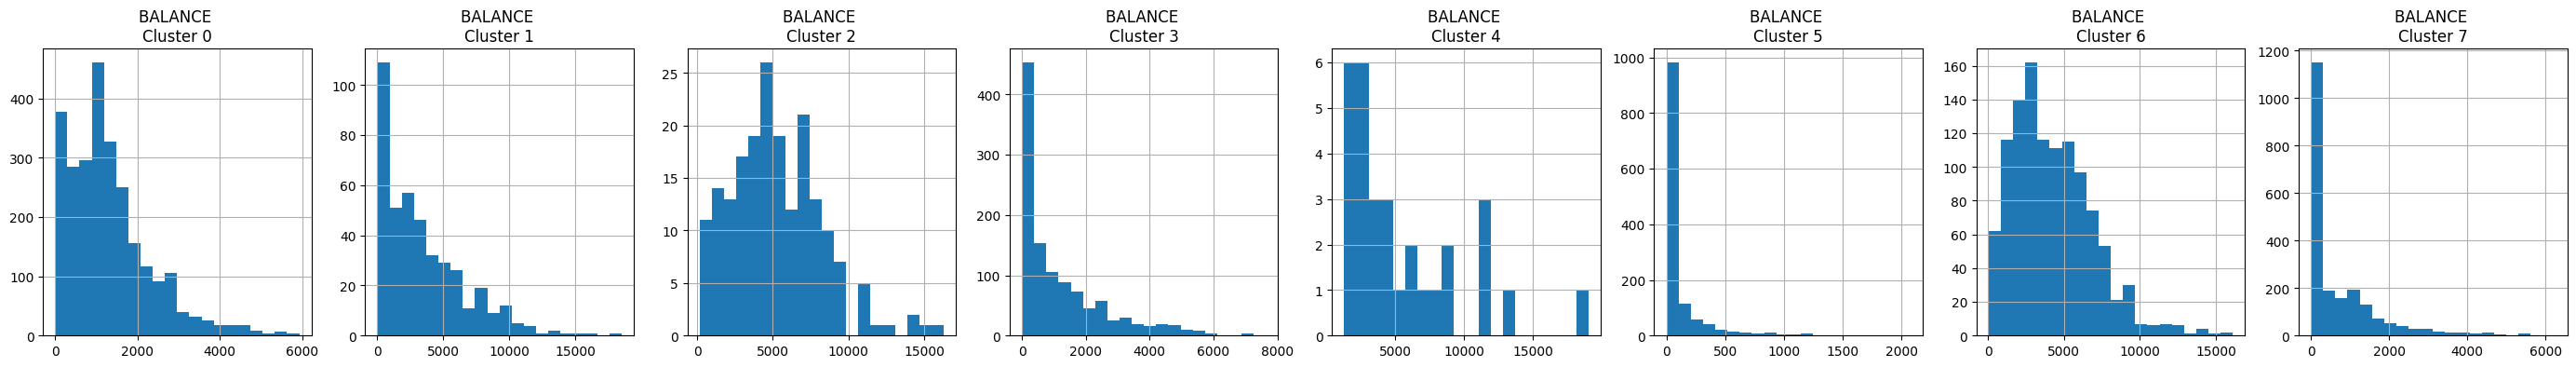

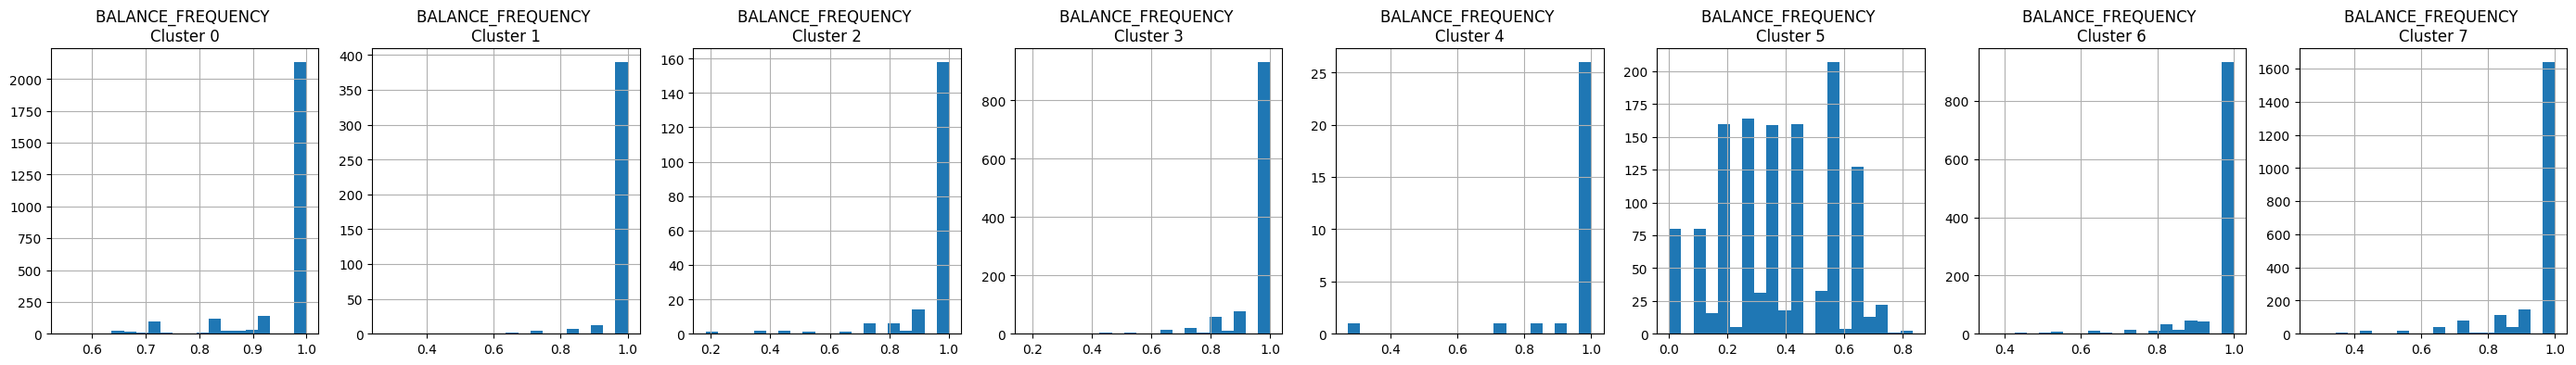

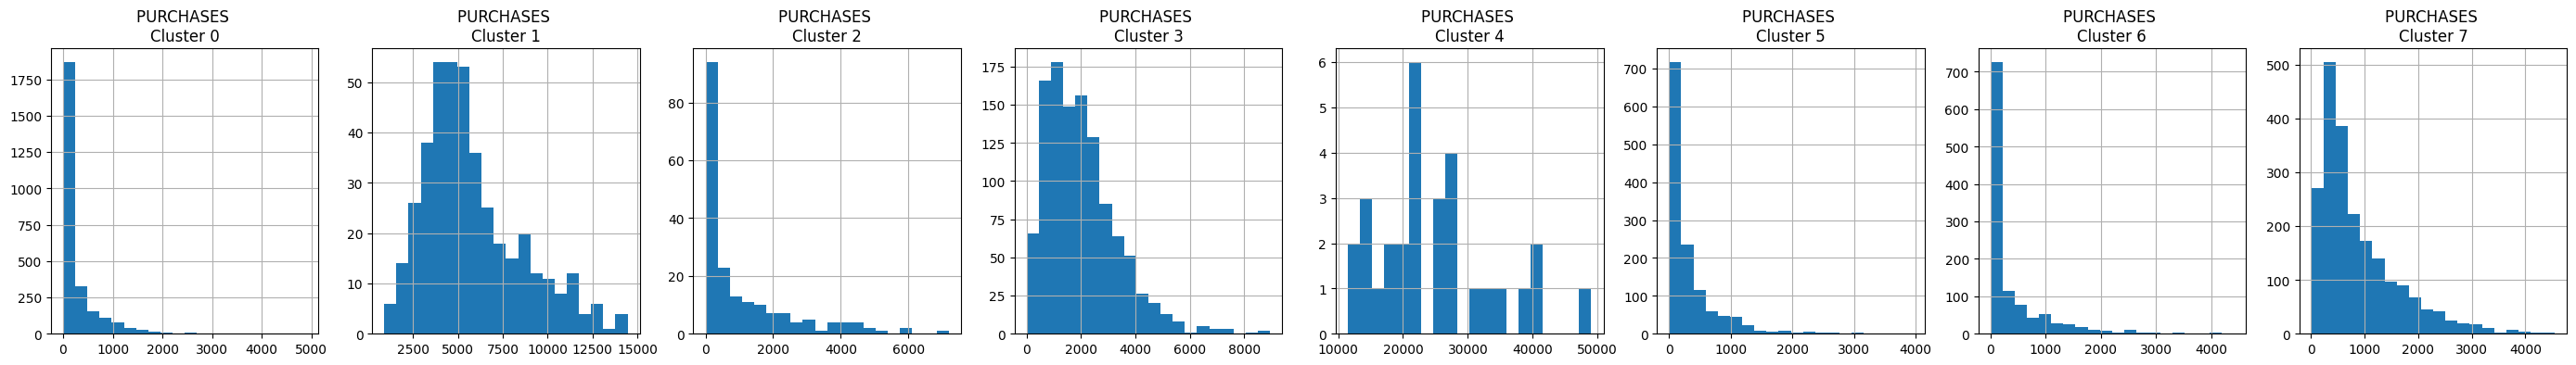

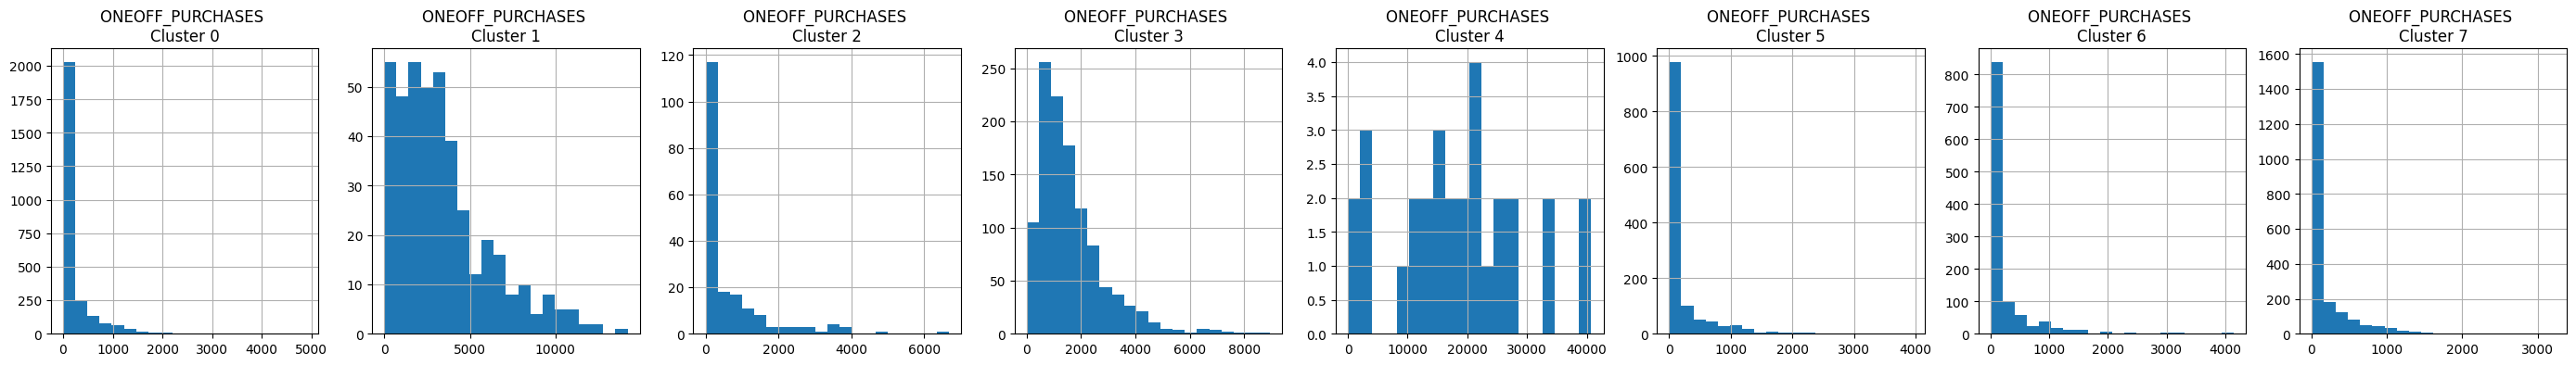

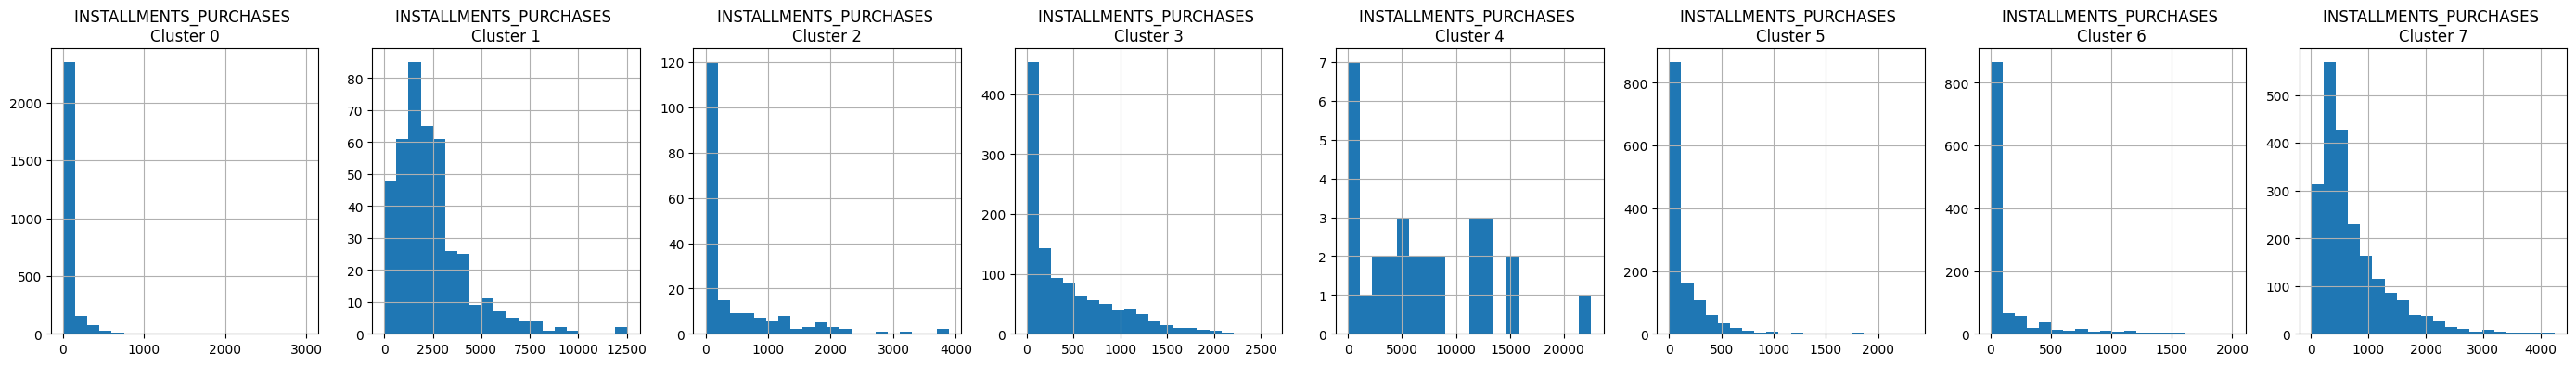

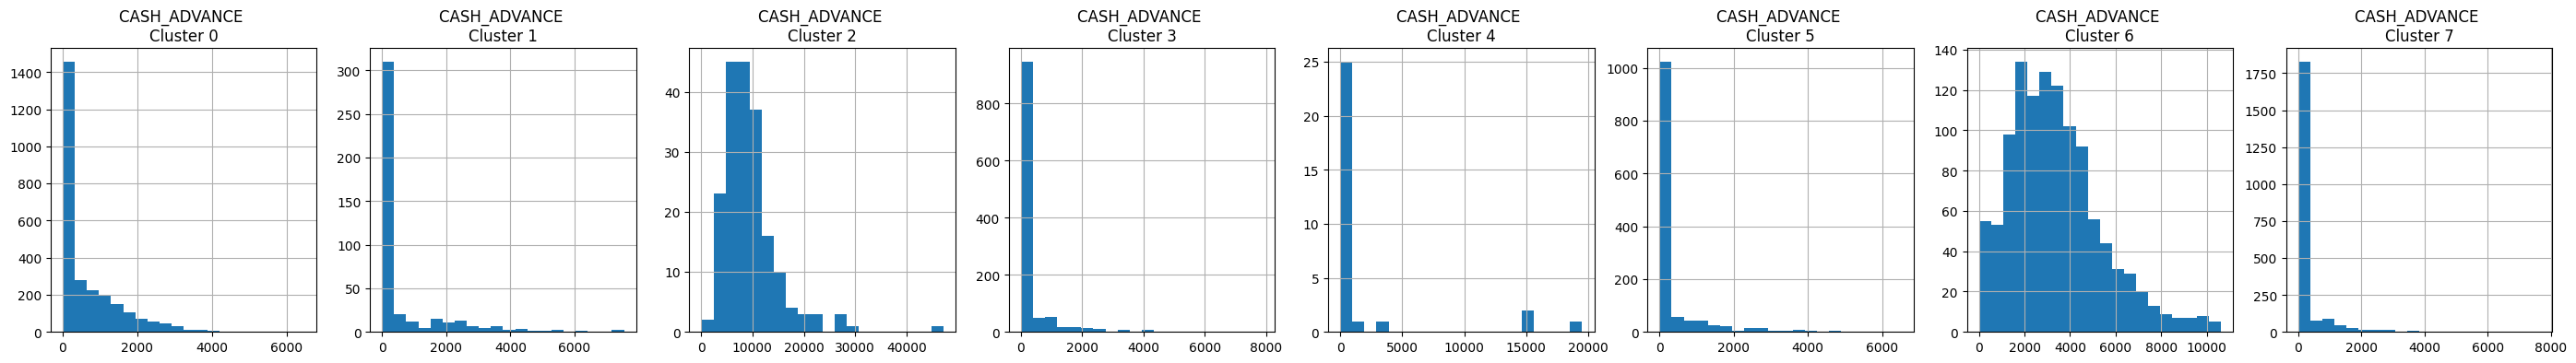

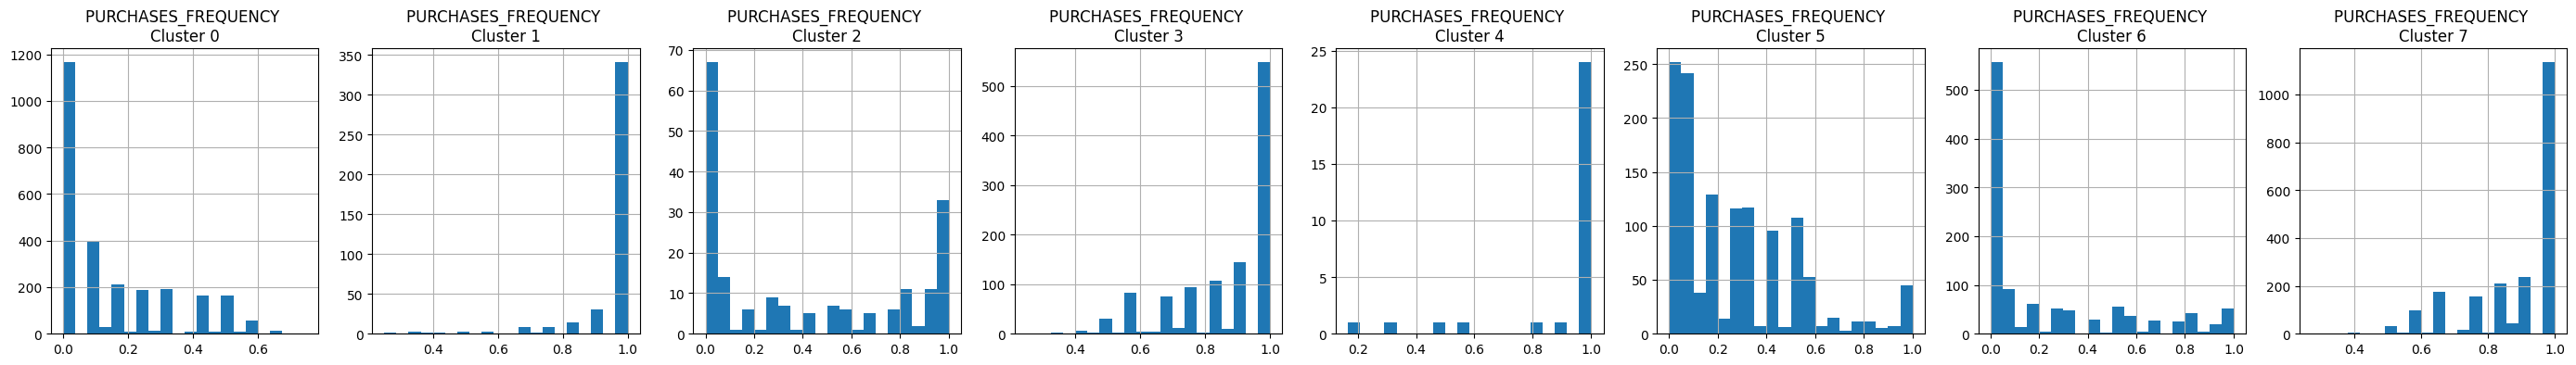

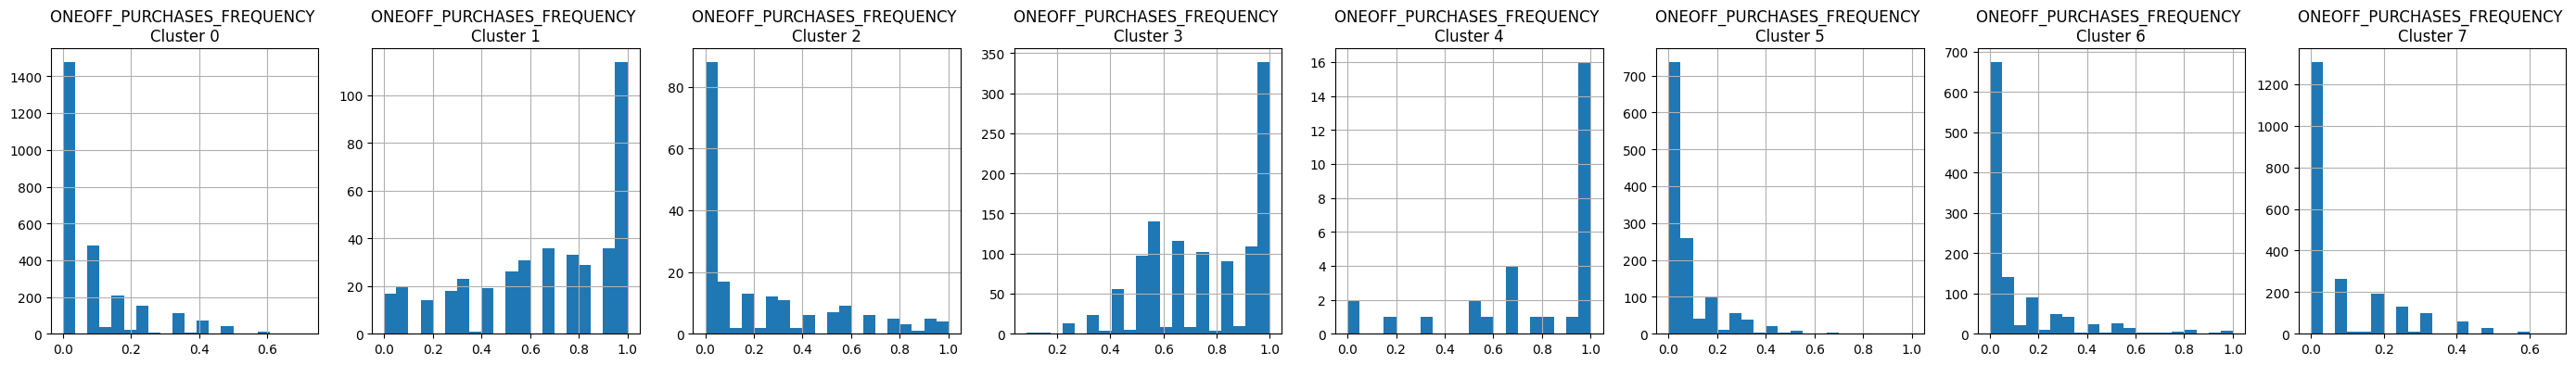

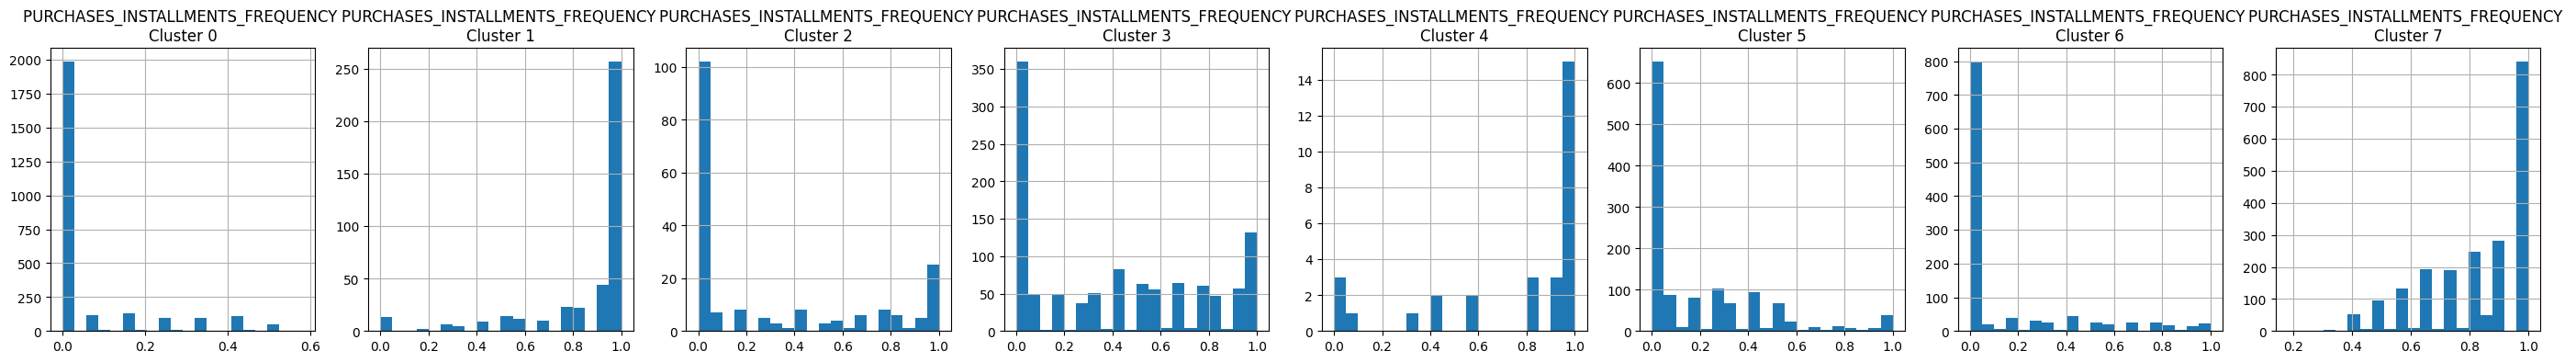

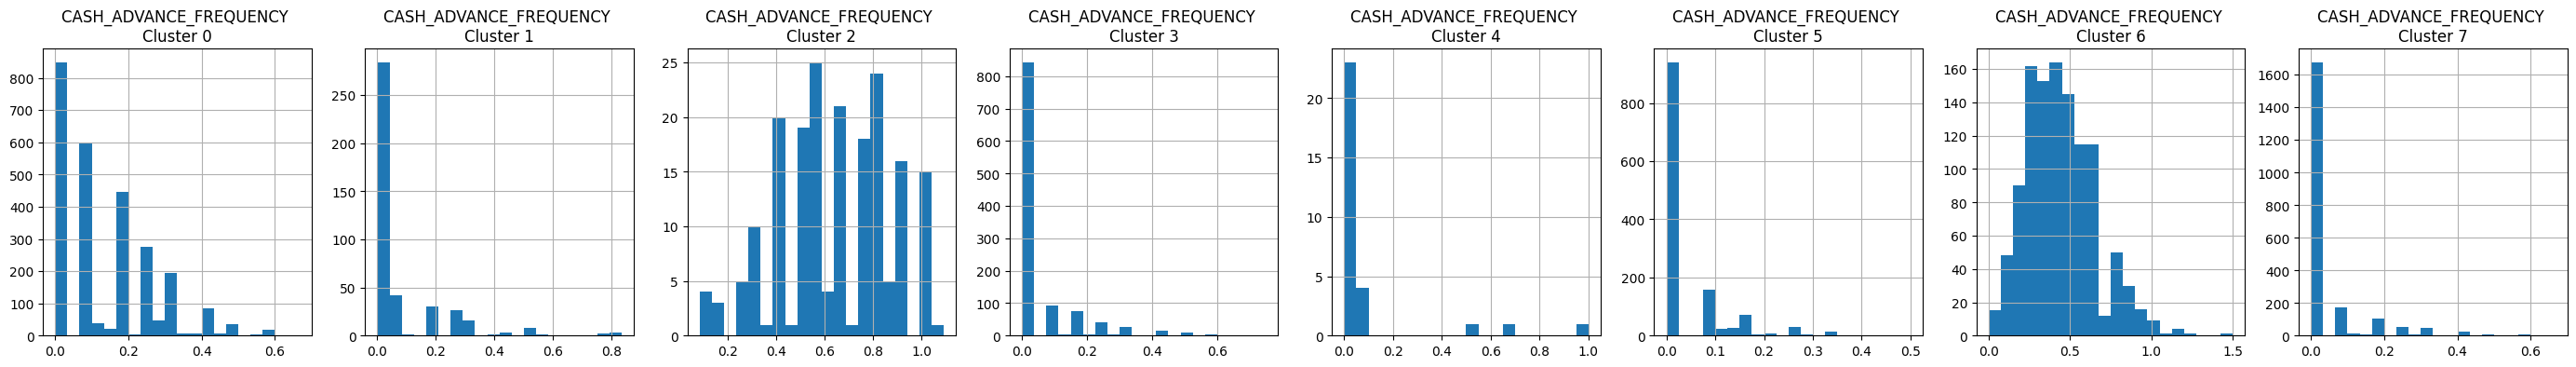

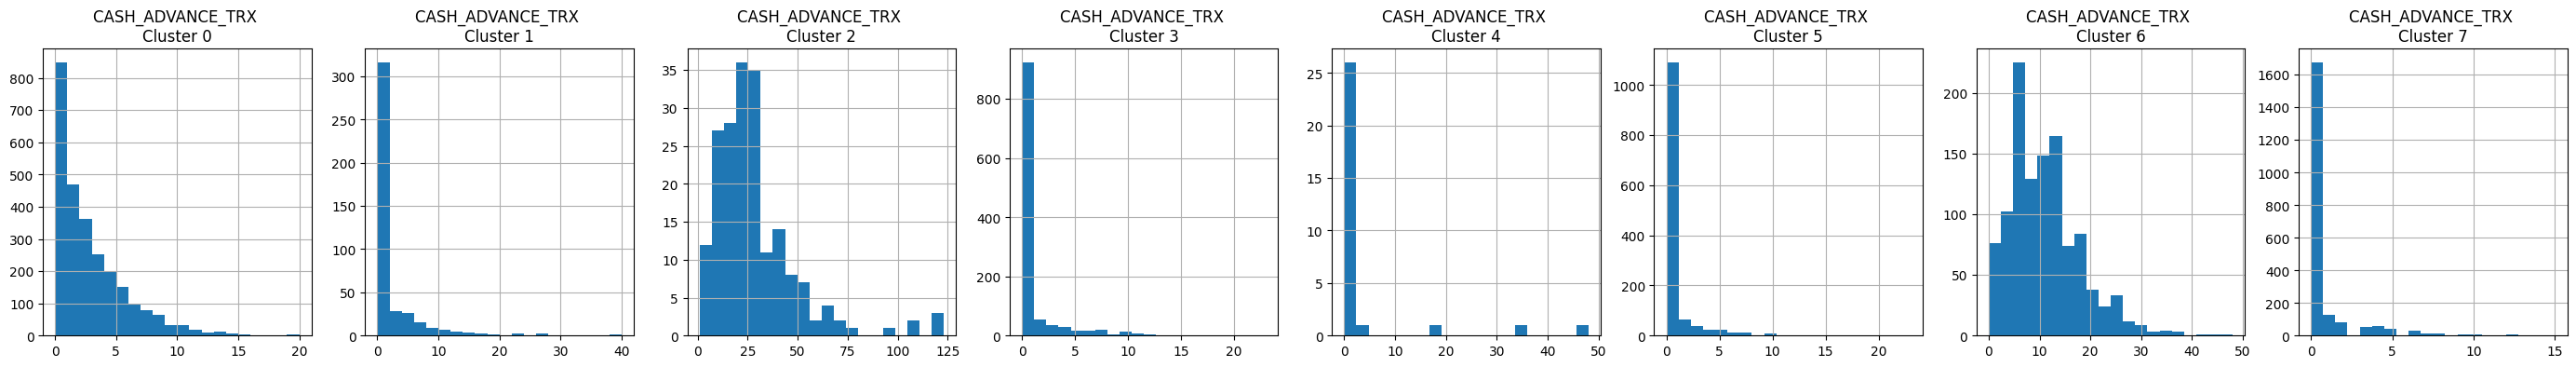

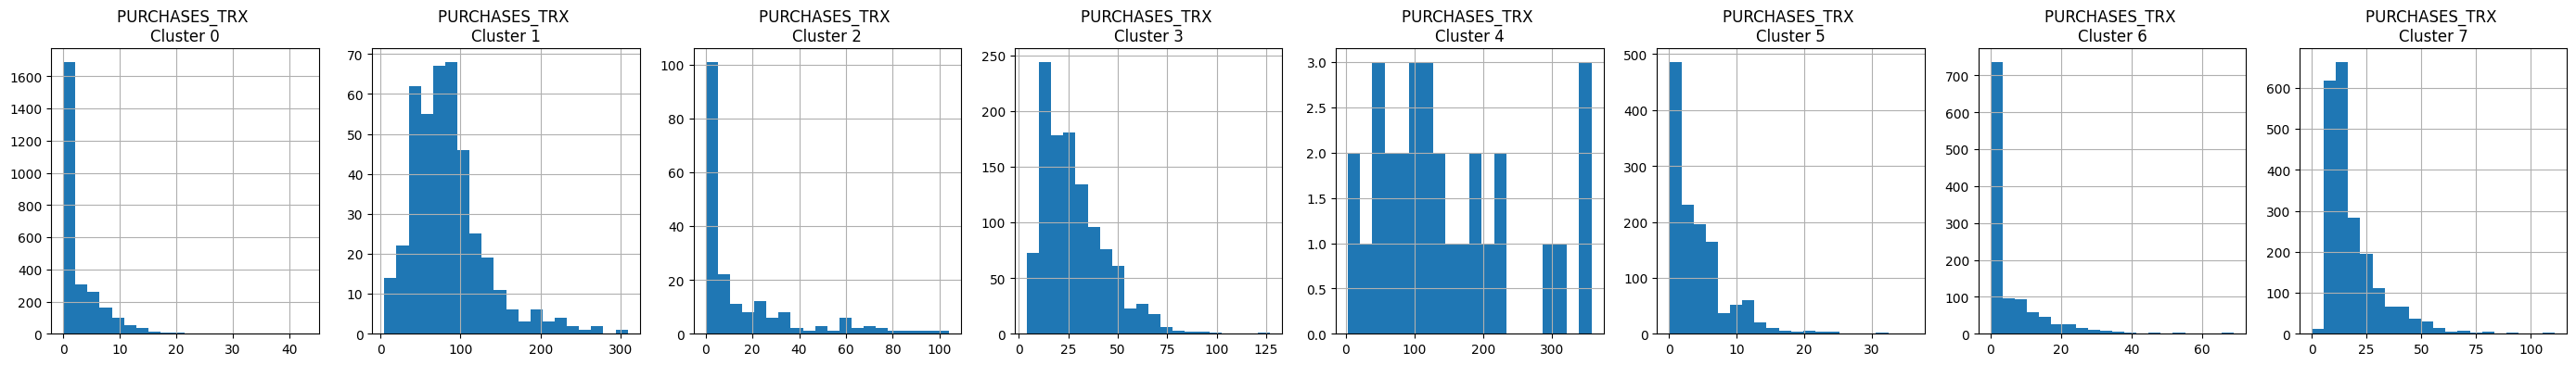

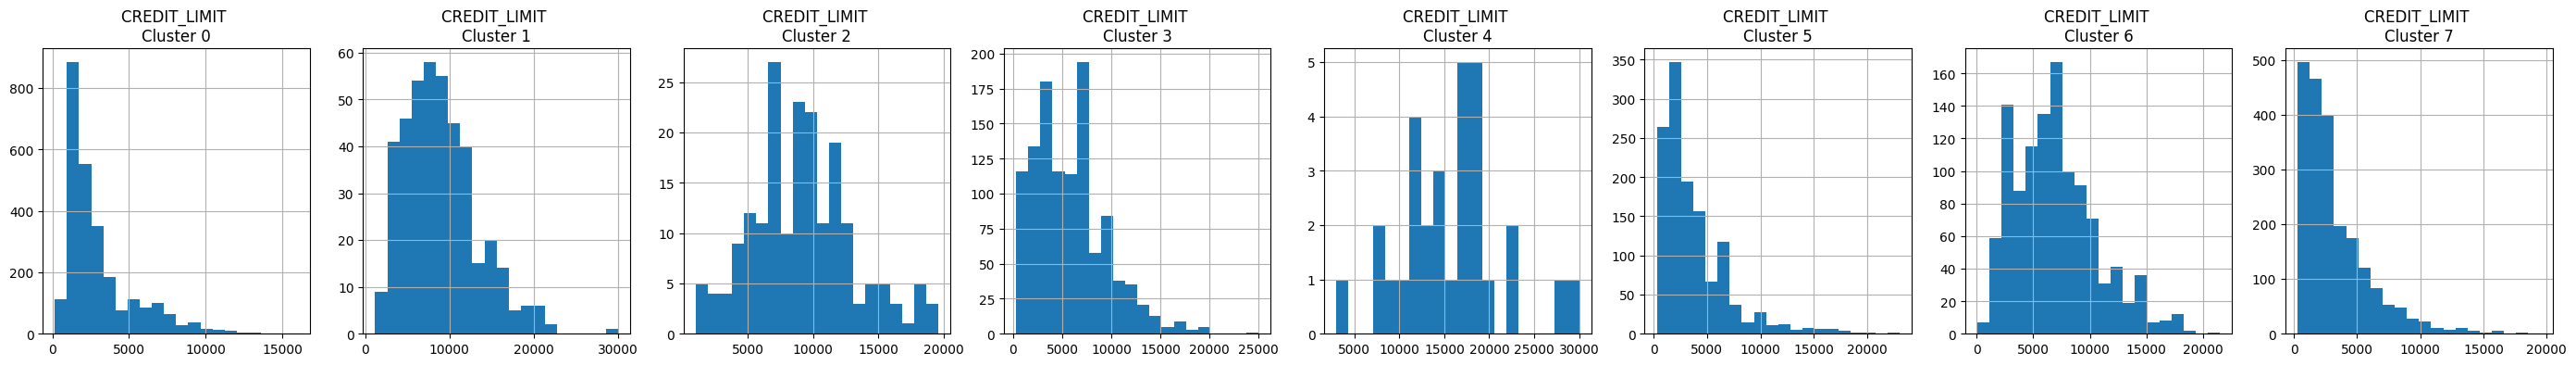

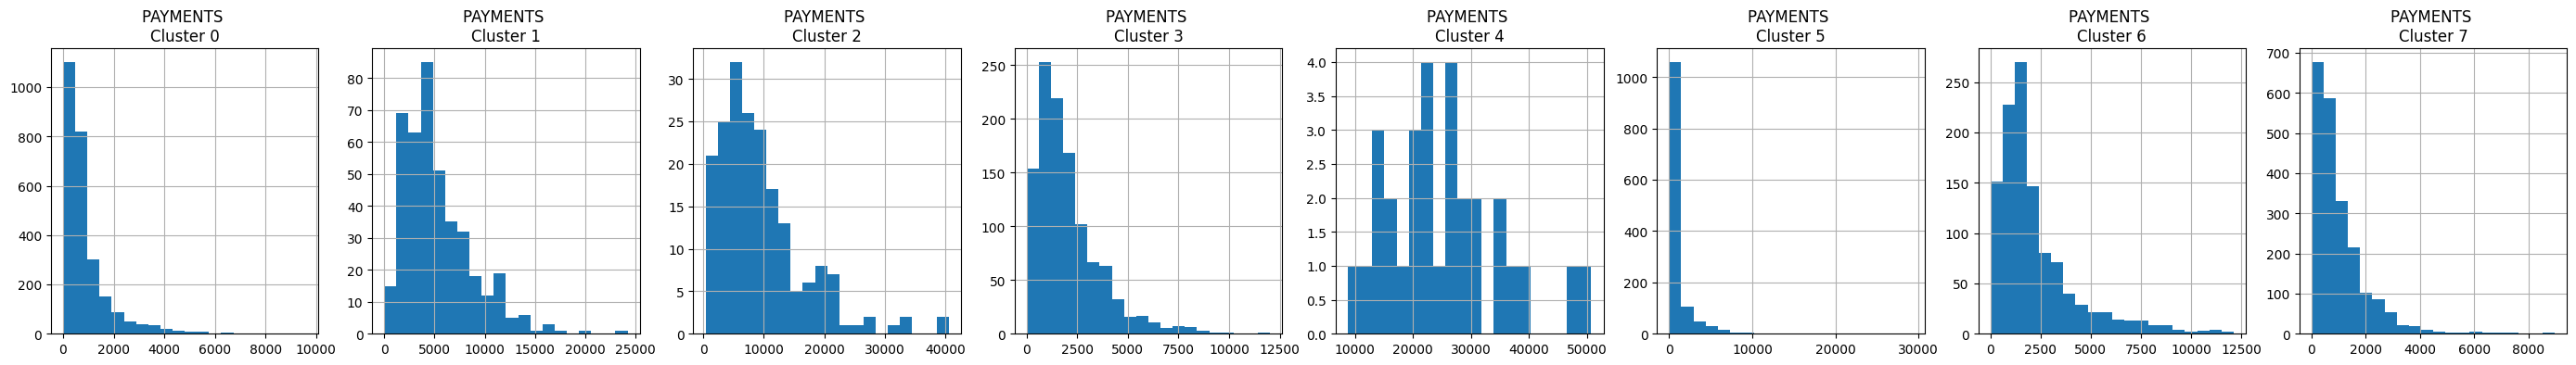

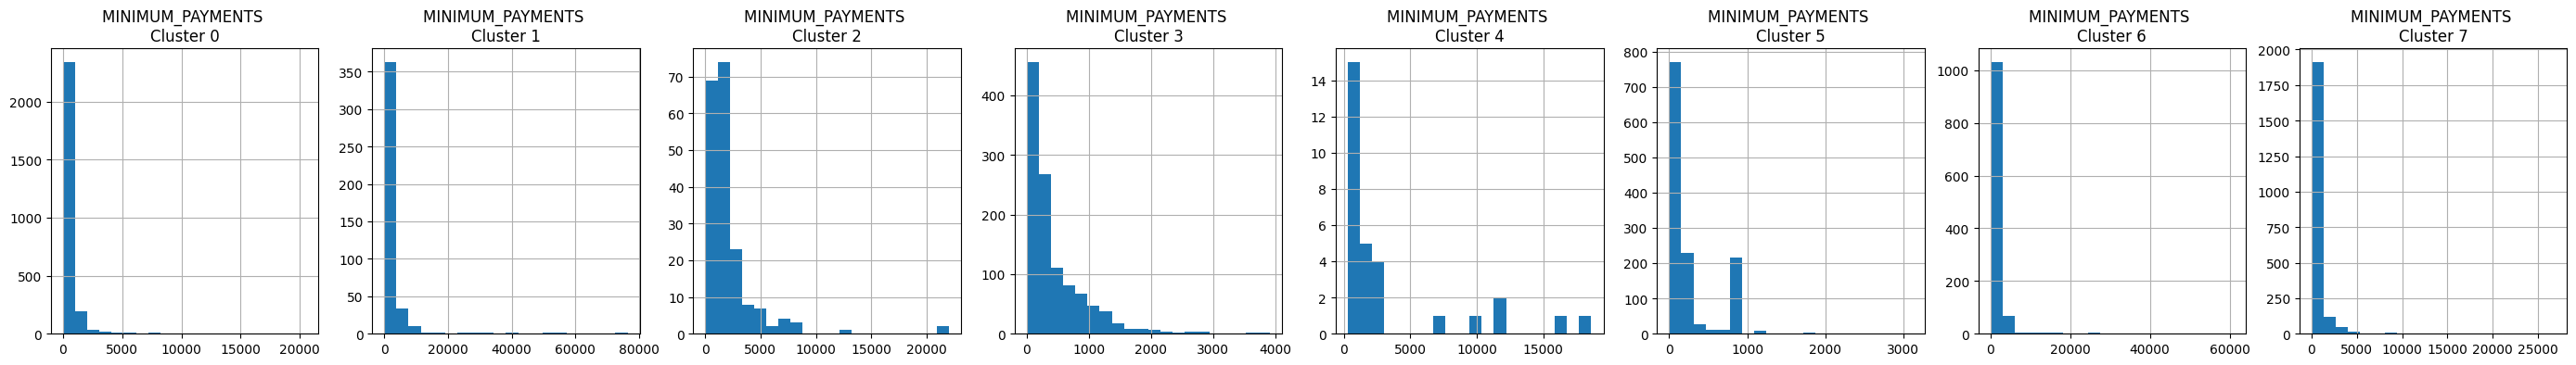

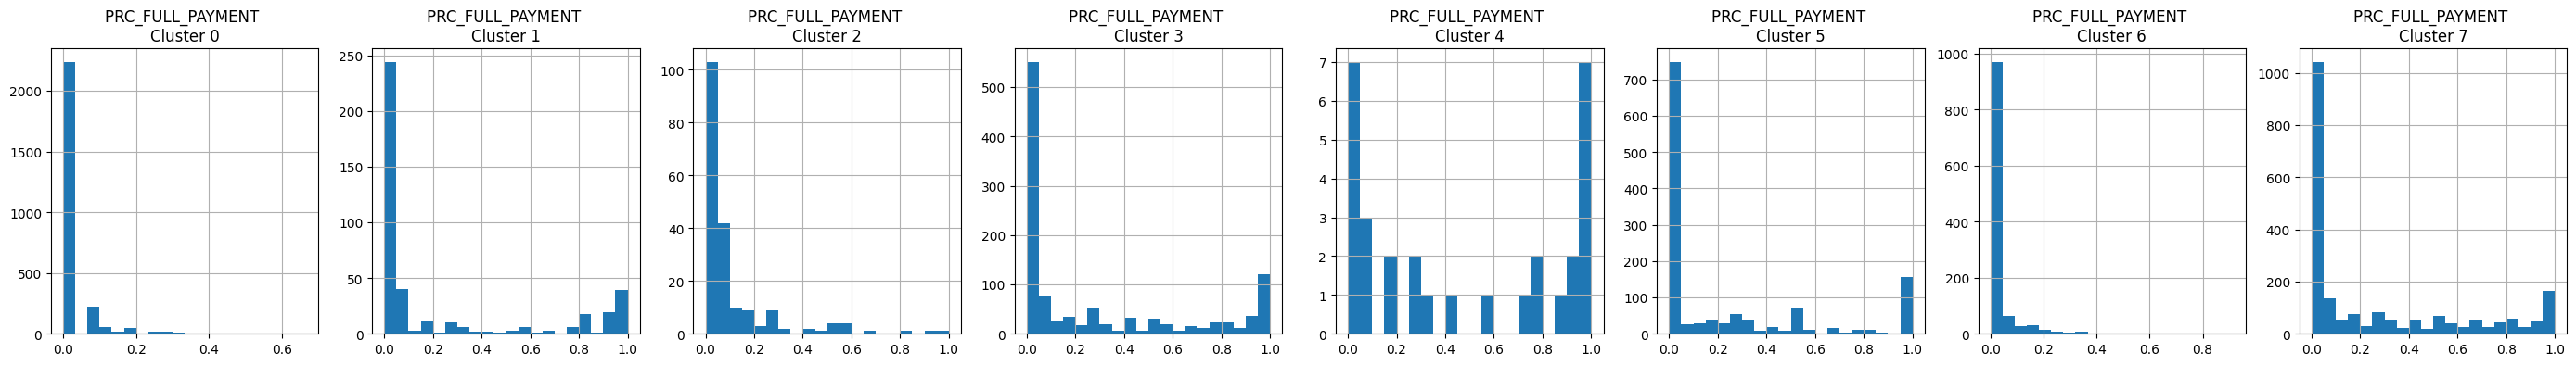

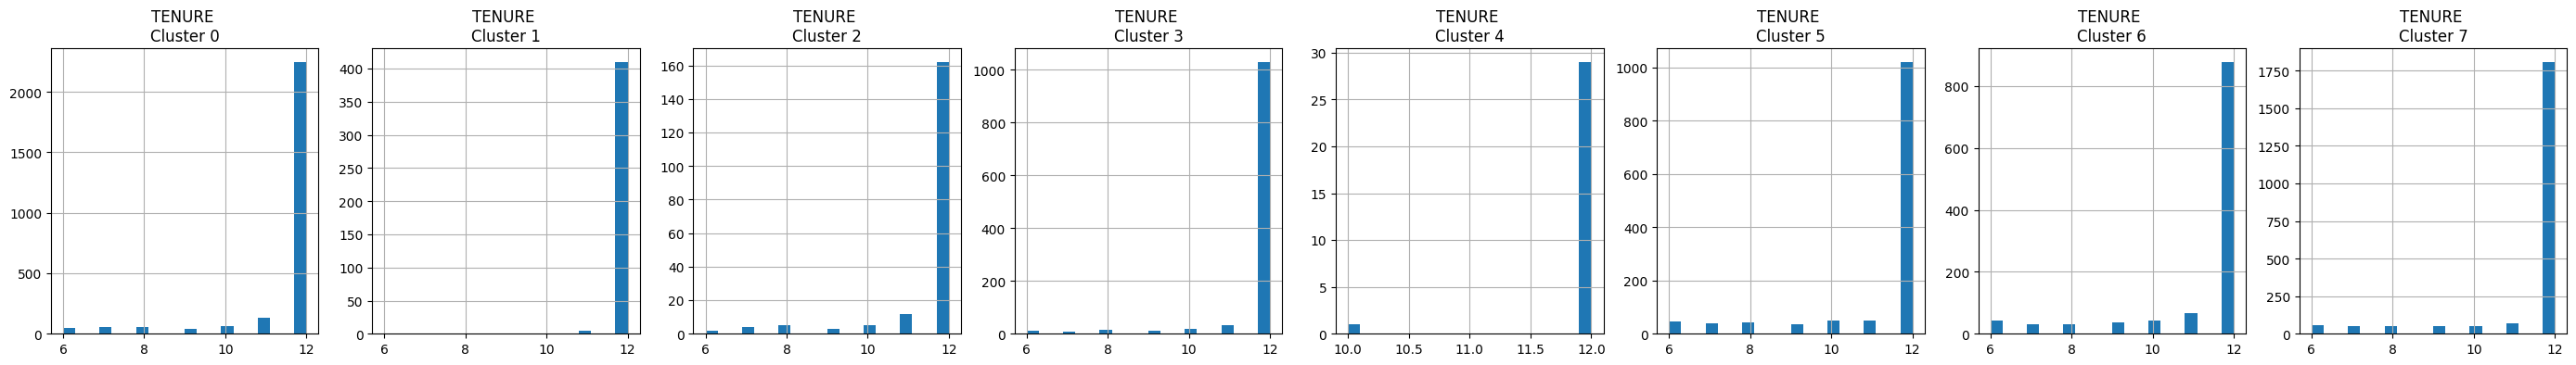

In [50]:
for i in credit_cards_df.columns:
  plt.figure(figsize = (35, 4))
  for j in range(8):
    plt.subplot(1, 8, j + 1)
    cluster = creditcard_df_cluster[creditcard_df_cluster["cluster"] == j]
    cluster[i].hist(bins = 20)
    plt.title("{} \nCluster {}".format(i, j))
  plt.show()

In [53]:
credit_ordered = creditcard_df_cluster.sort_values(by = "cluster")
credit_ordered.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
2103,1346.309166,1.0,652.13,567.76,84.37,0.000000,0.500000,0.416667,0.083333,0.000000,0,10,6000.0,385.145146,275.434078,0.00,12,0
6502,1699.100066,1.0,73.50,73.50,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1700.0,429.500066,992.881958,0.00,12,0
6504,545.819208,1.0,49.55,0.00,49.55,0.000000,0.250000,0.000000,0.250000,0.000000,0,3,2500.0,397.410932,247.041179,0.00,12,0
6509,1337.573860,1.0,0.00,0.00,0.00,36.473828,0.000000,0.000000,0.000000,0.083333,1,0,3000.0,395.385249,324.284676,0.00,12,0
6513,779.701771,1.0,116.66,0.00,116.66,2422.015644,0.166667,0.000000,0.083333,0.250000,6,6,1500.0,3378.436972,193.568746,0.25,12,0


In [54]:
credit_ordered.tail()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
22,132.342240,0.636364,815.90,0.0,815.90,0.0,1.000000,0.0,1.000000,0.0,0,17,1800.0,2359.629958,86.329554,0.00,12,7
20,2016.684686,1.000000,176.68,0.0,176.68,0.0,0.666667,0.0,0.666667,0.0,0,8,2000.0,223.068600,13557.297260,0.00,12,7
8945,28.493517,1.000000,291.12,0.0,291.12,0.0,1.000000,0.0,0.833333,0.0,0,6,1000.0,325.594462,48.886365,0.50,6,7
8946,19.183215,1.000000,300.00,0.0,300.00,0.0,1.000000,0.0,0.833333,0.0,0,6,1000.0,275.861322,864.206542,0.00,6,7
8947,23.398673,0.833333,144.40,0.0,144.40,0.0,0.833333,0.0,0.666667,0.0,0,5,1000.0,81.270775,82.418369,0.25,6,7


In [55]:
credit_ordered.to_csv("cluster_marketing.csv")

 ## Aplicanção de PCA (principal component analysis) e visualização dos resultados

In [57]:
pca = PCA(n_components = 2)
principal_comp = pca.fit_transform(credit_cards_df_scaled)
principal_comp


array([[-1.68222026, -1.07645061],
       [-1.1382949 ,  2.50647666],
       [ 0.96968401, -0.3835203 ],
       ...,
       [-0.92620364, -1.8107856 ],
       [-2.33655167, -0.65796601],
       [-0.55642216, -0.40046712]])

In [58]:
pca_df = pd.DataFrame(data = principal_comp, columns = ["pca1", "pca2"])
pca_df.head()

,pca1,pca2
0,-1.682220,-1.076451
1,-1.138295,2.506477
2,0.969684,-0.383520
3,-0.873628,0.043166
4,-1.599434,-0.688581


In [59]:
pca_df = pd.concat([pca_df, pd.DataFrame({"cluster": labels})], axis = 1)
pca_df

,pca1,pca2,cluster
0,-1.682220,-1.076451,0
1,-1.138295,2.506477,6
2,0.969684,-0.383520,3
3,-0.873628,0.043166,0
4,-1.599434,-0.688581,0
...,...,...,...
8945,-0.359629,-2.016145,7
8946,-0.564369,-1.639123,7
8947,-0.926204,-1.810786,7
8948,-2.336552,-0.657966,0


<Axes: xlabel='pca1', ylabel='pca2'>

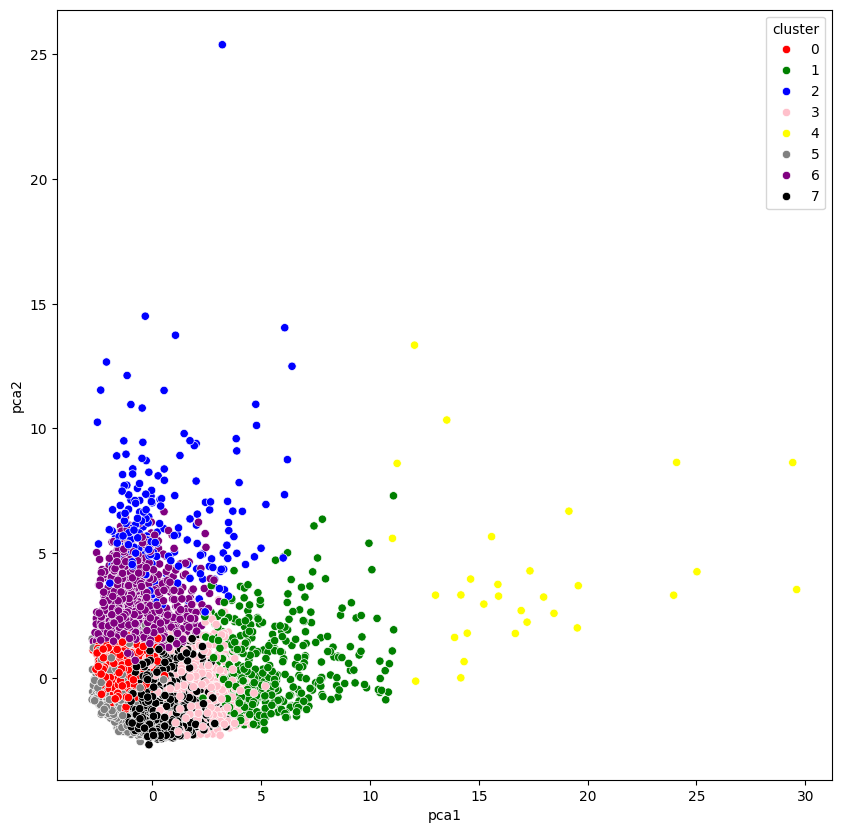

In [61]:
plt.figure(figsize = (10, 10))
sns.scatterplot(x = "pca1", y = "pca2", hue = "cluster", data = pca_df, palette = ["red", "green", "blue", "pink", "yellow", "gray", "purple", "black"])